In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.offline as pyo
import plotly.graph_objects as go
import plotly.express as px

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [2]:
df = yf.download(['RELIANCE.NS', 'HDFCBANK.NS', 'TCS.NS', '^NSEI', 'GC=F'], start='2015-01-01', end ='2026-01-31')['Close']
df

[*********************100%***********************]  5 of 5 completed


Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-01,NaN,217.235352,189.999802,988.879761,NaN
2015-01-02,1186.000000,220.258682,189.496933,1002.049072,8395.450195
2015-01-05,1203.900024,218.399048,187.421249,986.820923,8378.400391
2015-01-06,1219.300049,214.999207,178.915253,950.440125,8127.350098
2015-01-07,1210.599976,215.626724,182.809814,939.213379,8102.100098
...,...,...,...,...,...
2026-01-26,5079.700195,NaN,NaN,NaN,NaN
2026-01-27,5079.899902,926.400024,1380.500000,3158.000000,25175.400391
2026-01-28,5301.600098,932.700012,1396.699951,3200.100098,25342.750000


In [5]:
df = df.dropna()
df

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-02,1186.000000,220.258682,189.496933,1002.049072,8395.450195
2015-01-05,1203.900024,218.399048,187.421249,986.820923,8378.400391
2015-01-06,1219.300049,214.999207,178.915253,950.440125,8127.350098
2015-01-07,1210.599976,215.626724,182.809814,939.213379,8102.100098
2015-01-08,1208.400024,220.156006,180.188477,949.352844,8234.599609
...,...,...,...,...,...
2026-01-23,4976.200195,916.099976,1386.099976,3162.500000,25048.650391
2026-01-27,5079.899902,926.400024,1380.500000,3158.000000,25175.400391
2026-01-28,5301.600098,932.700012,1396.699951,3200.100098,25342.750000


In [7]:
log_returns = np.log(df/df.shift(1)).dropna()

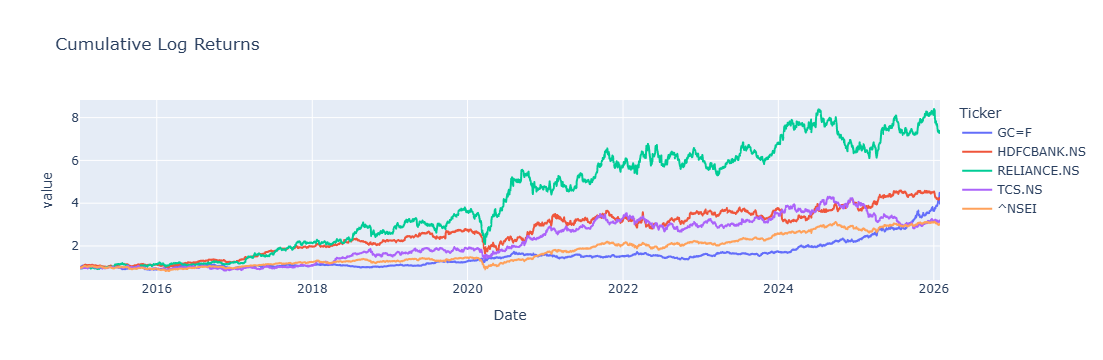

In [75]:
daily_cum_returns = np.exp(log_returns.cumsum())
daily_cum_returns.plot(title='Cumulative Log Returns')

# Drawdowns

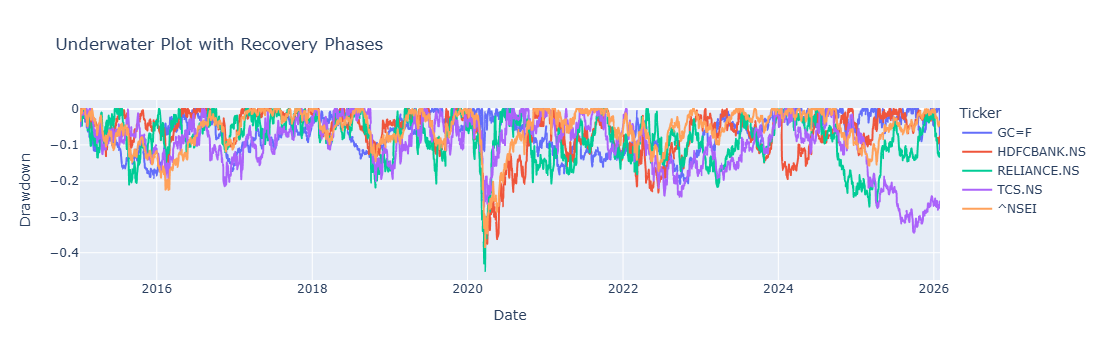

In [12]:
peak = daily_cum_returns.cummax()

drawdown = daily_cum_returns / peak - 1

drawdown.plot(title="Underwater Plot with Recovery Phases",
             labels={"value": "Drawdown", "index": "Date"})

# Maximum Drawdown

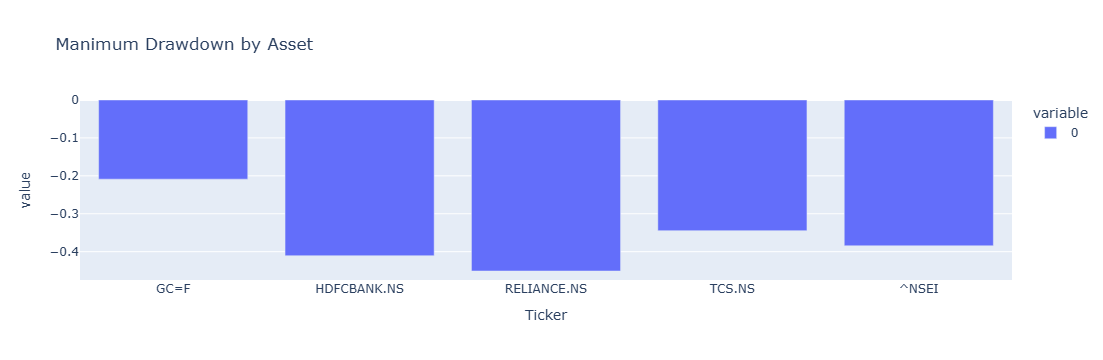

In [15]:
max_dd = drawdown.min()
max_dd.plot(kind='bar', title='Manimum Drawdown by Asset')

In [43]:
daily_cum_returns = np.exp(log_returns.cumsum())
series = daily_cum_returns['^NSEI']

peak = series.cummax()
underwater = series < peak

recovery_durations = []
duration = 0

for is_underwater in underwater:
    if is_underwater:
        duration += 1
    else:
        if duration > 0:
            recovery_durations.append(duration)
            duration = 0

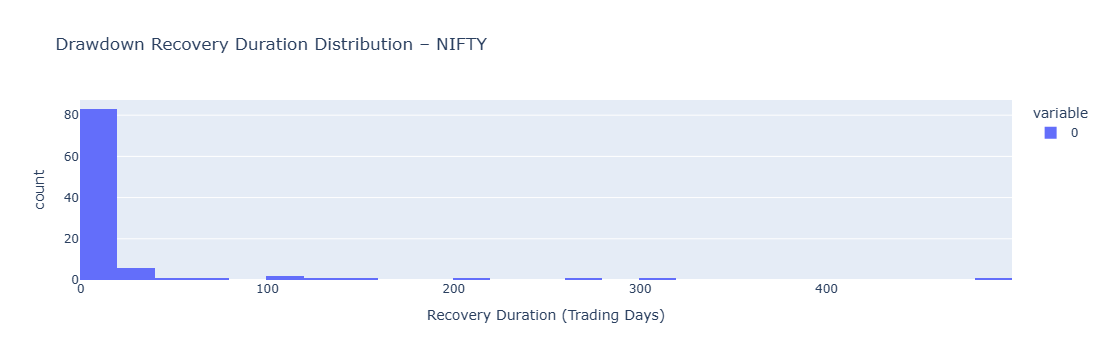

In [45]:
px.histogram(
    recovery_durations,
    nbins=30,
    title="Drawdown Recovery Duration Distribution – NIFTY",
    labels={"value": "Recovery Duration (Trading Days)", "count": "Frequency"}
).show()

In [47]:
daily_cum_returns = np.exp(log_returns.cumsum())
series = daily_cum_returns['RELIANCE.NS']

peak = series.cummax()
underwater = series < peak

recovery_durations = []
duration = 0

for is_underwater in underwater:
    if is_underwater:
        duration += 1
    else:
        if duration > 0:
            recovery_durations.append(duration)
            duration = 0

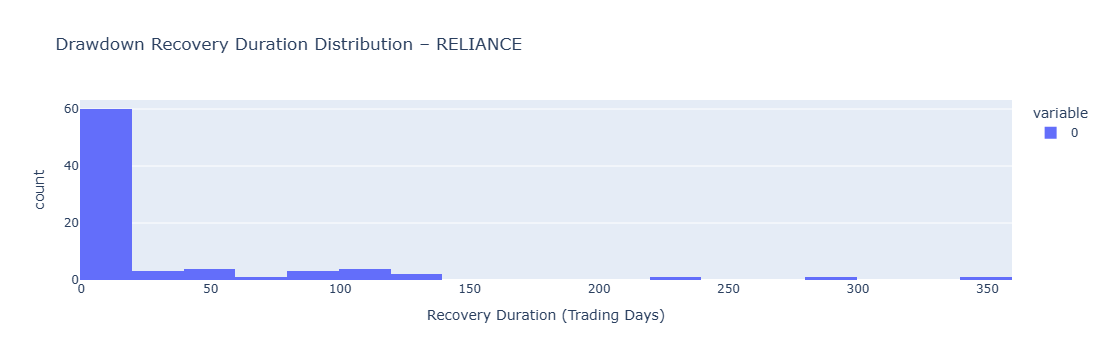

In [49]:
px.histogram(
    recovery_durations,
    nbins=30,
    title="Drawdown Recovery Duration Distribution – RELIANCE",
    labels={"value": "Recovery Duration (Trading Days)", "count": "Frequency"}
).show()

In [51]:
daily_cum_returns = np.exp(log_returns.cumsum())
series = daily_cum_returns['HDFCBANK.NS']

peak = series.cummax()
underwater = series < peak

recovery_durations = []
duration = 0

for is_underwater in underwater:
    if is_underwater:
        duration += 1
    else:
        if duration > 0:
            recovery_durations.append(duration)
            duration = 0

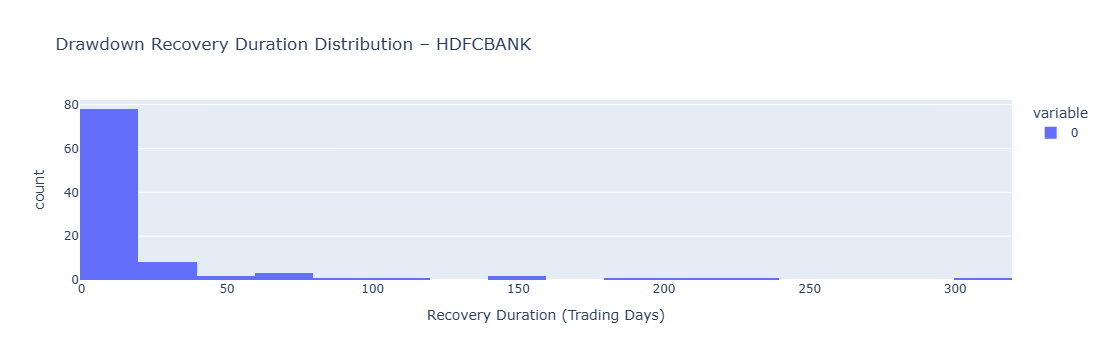

In [53]:
px.histogram(
    recovery_durations,
    nbins=30,
    title="Drawdown Recovery Duration Distribution – HDFCBANK",
    labels={"value": "Recovery Duration (Trading Days)", "count": "Frequency"}
).show()

In [55]:
daily_cum_returns = np.exp(log_returns.cumsum())
series = daily_cum_returns['TCS.NS']

peak = series.cummax()
underwater = series < peak

recovery_durations = []
duration = 0

for is_underwater in underwater:
    if is_underwater:
        duration += 1
    else:
        if duration > 0:
            recovery_durations.append(duration)
            duration = 0

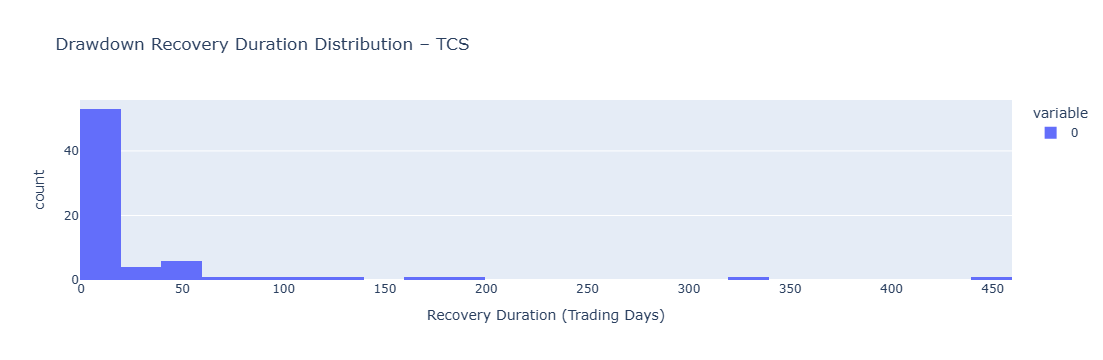

In [57]:
px.histogram(
    recovery_durations,
    nbins=30,
    title="Drawdown Recovery Duration Distribution – TCS",
    labels={"value": "Recovery Duration (Trading Days)", "count": "Frequency"}
).show()

In [67]:
daily_cum_returns = np.exp(log_returns.cumsum())
series = daily_cum_returns['GC=F']

peak = series.cummax()
underwater = series < peak

recovery_durations = []
duration = 0

for is_underwater in underwater:
    if is_underwater:
        duration += 1
    else:
        if duration > 0:
            recovery_durations.append(duration)
            duration = 0

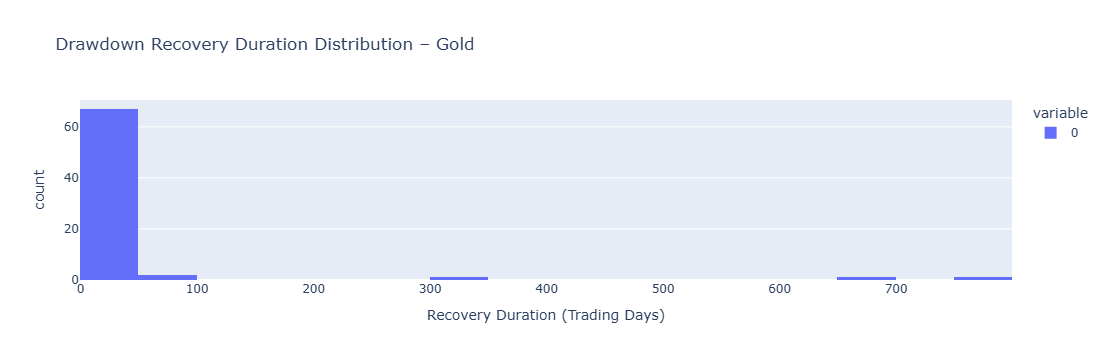

In [69]:
px.histogram(
    recovery_durations,
    nbins=30,
    title="Drawdown Recovery Duration Distribution – Gold",
    labels={"value": "Recovery Duration (Trading Days)", "count": "Frequency"}
).show()